# Stage 1: Define Prediction Grid

Creates cluster-sized prediction points across 10 target provinces + NCR.
Uses **PSGC shapefiles** from [altcoder/philippines-psgc-shapefiles](https://github.com/altcoder/philippines-psgc-shapefiles) which have the updated Maguindanao del Norte / del Sur split.

**Target areas (5 lowest poverty incidence):**
- Ilocos Norte (0.3%), Pampanga (1.0%), Benguet (2.5%), Kalinga (2.6%), Aklan (3.1%)

**Target areas (5 highest poverty incidence):**
- Zamboanga del Norte (37.7%), Basilan (33.7%), Tawi-Tawi (32.3%), Maguindanao del Sur (32.1%), Davao Oriental (29.1%)

**Plus:** NCR

**Output:** `prediction_points.csv`

In [67]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')
print(f"GeoPandas: {gpd.__version__}")

GeoPandas: 1.1.2


In [68]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

# PSGC shapefiles from: https://github.com/altcoder/philippines-psgc-shapefiles
# Unzip PH_Adm3_MuniCities.shp.zip
PSGC_DIR = '/Users/ruben/Desktop/Thesis/2025Data/'
MUNI_SHP = f'{PSGC_DIR}/PH_Adm3_MuniCities.shp'
#PROV_SHP = f'{PSGC_DIR}/PH_Adm2_ProvDists.shp'

# DHS cluster shapefile
DHS_SHP = '/Users/ruben/Desktop/Thesis/TrainingData/PH_DHS_GPS/PHGE81FL/PHGE81FL.shp'

# Output
OUTPUT_DIR = '/Users/ruben/Desktop/Thesis/2025Data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

GRID_RURAL_M = 5000
GRID_URBAN_M = 2000
PH_CRS = 'EPSG:32651'

TARGET_PROVINCES = [
    'Ilocos Norte', 'Pampanga', 'Benguet', 'Kalinga', 'Aklan',
    'Zamboanga del Norte', 'Basilan', 'Tawi-Tawi',
    'Maguindanao del Sur', 'Davao Oriental',
]

NCR_REGION_NAME = 'NCR'
SEED = 42
np.random.seed(SEED)

print(f"Target: {len(TARGET_PROVINCES)} provinces + NCR")

Target: 10 provinces + NCR


In [69]:
# ============================================================
# 2. LOAD MUNICIPALITIES AND FILTER VIA P-CODE DICTIONARY
# ============================================================

# The dictionary derived directly from the official UN OCHA CSVs
# Maps Province Name -> PSGC Prefix
PROVINCE_PREFIXES = {
    'Ilocos Norte': '1028',
    'Pampanga': '3054',
    'Benguet': '14011',
    'Kalinga': '14032',
    'Aklan': '6004',
    'Zamboanga del Norte': '9072',
    'Basilan': '19007',
    'Tawi-Tawi': '19070',
    'Maguindanao del Sur': '19088', # Updated Maguindanao split code!
    'Davao Oriental': '11025',
    'NCR': '13'  # All NCR municipalities start with 13
}

print("Loading PSGC municipality boundaries...")
gdf_muni = gpd.read_file(MUNI_SHP)

# Force columns to lowercase to prevent capitalization errors
gdf_muni.columns = gdf_muni.columns.str.lower()

# Clean PSGC codes (remove any accidental .0 and ensure they are strings)
gdf_muni['psgc_code'] = gdf_muni['psgc_code'].astype(str).str.replace('.0', '', regex=False)

# Create empty columns for our standard naming convention
gdf_muni['Province'] = None
gdf_muni['Municipality'] = gdf_muni['name']

print("Applying Province labels via PSGC prefixes...")

# Map the provinces by checking if the municipality code starts with the dictionary prefix
for prov, prefix in PROVINCE_PREFIXES.items():
    mask = gdf_muni['psgc_code'].str.startswith(prefix)
    gdf_muni.loc[mask, 'Province'] = prov

# Filter down to ONLY our target areas (anything that successfully got a Province name)
gdf_target = gdf_muni[gdf_muni['Province'].notna()].copy()

# Flag NCR for the grid logic later
gdf_target['is_ncr'] = gdf_target['Province'] == 'NCR'

print(f"\nFiltered to {len(gdf_target)} municipalities across:")
for prov, count in gdf_target['Province'].value_counts().items():
    print(f"  {prov}: {count} municipalities")

gdf_target = gdf_target.to_crs(PH_CRS)
print(f"\nReprojected to {PH_CRS}")

Loading PSGC municipality boundaries...
Applying Province labels via PSGC prefixes...

Filtered to 184 municipalities across:
  Zamboanga del Norte: 27 municipalities
  Maguindanao del Sur: 24 municipalities
  Ilocos Norte: 23 municipalities
  Pampanga: 21 municipalities
  Aklan: 17 municipalities
  NCR: 17 municipalities
  Benguet: 13 municipalities
  Basilan: 12 municipalities
  Davao Oriental: 11 municipalities
  Tawi-Tawi: 11 municipalities
  Kalinga: 8 municipalities

Reprojected to EPSG:32651


In [70]:
# ============================================================
# 3. CREATE GRID POINTS
# ============================================================
# Map the old variables to our clean, dictionary-derived columns
COL_PROVINCE = 'Province'
COL_MUNI     = 'Municipality'
COL_PCODE    = 'psgc_code'
COL_REGION   = 'adm1_pcode' # The raw region code from the shapefile
def generate_grid_within_polygon(polygon, spacing_m):
    minx, miny, maxx, maxy = polygon.bounds
    xs = np.arange(minx, maxx, spacing_m)
    ys = np.arange(miny, maxy, spacing_m)
    points = []
    for x in xs:
        for y in ys:
            pt = Point(x, y)
            if polygon.contains(pt):
                points.append(pt)
    return points

print("Generating prediction grid...")
all_points = []
point_id = 1

for idx, row in gdf_target.iterrows():
    municipality = row[COL_MUNI]
    province = row[COL_PROVINCE]
    region = row[COL_REGION]
    is_ncr = row['is_ncr']
    pcode = row.get(COL_PCODE, None)

    spacing = GRID_URBAN_M if is_ncr else GRID_RURAL_M
    polygon = row.geometry
    if polygon is None or polygon.is_empty:
        continue

    if polygon.geom_type == 'MultiPolygon':
        sub_polys = list(polygon.geoms)
    else:
        sub_polys = [polygon]

    muni_points = []
    for poly in sub_polys:
        pts = generate_grid_within_polygon(poly, spacing)
        muni_points.extend(pts)

    if len(muni_points) == 0:
        centroid = polygon.centroid
        if polygon.contains(centroid):
            muni_points = [centroid]
        else:
            muni_points = [polygon.representative_point()]

    for pt in muni_points:
        all_points.append({
            'PointID': point_id,
            'Municipality': municipality,
            'Province': province,
            'Region': region,
            'PSGC': pcode,
            'is_ncr': is_ncr,
            'geometry': pt
        })
        point_id += 1

gdf_points = gpd.GeoDataFrame(all_points, crs=PH_CRS)
print(f"\nTotal grid points: {len(gdf_points)}")
for prov, count in gdf_points['Province'].value_counts().items():
    print(f"  {prov}: {count}")

Generating prediction grid...

Total grid points: 1162
  Zamboanga del Norte: 233
  Davao Oriental: 187
  NCR: 139
  Ilocos Norte: 112
  Kalinga: 107
  Benguet: 101
  Maguindanao del Sur: 82
  Pampanga: 75
  Aklan: 55
  Tawi-Tawi: 36
  Basilan: 35


In [71]:
# ============================================================
# 3B. CHECK DENSITY
# ============================================================

muni_counts = gdf_points.groupby(
    ['Province', 'Municipality']
).size().reset_index(name='n_points')
print("Points per municipality (top 20):")
print(muni_counts.sort_values('n_points', ascending=False).head(20).to_string(index=False))
print(f"\nMunicipalities with 1 point: {(muni_counts['n_points'] == 1).sum()}")
print(f"Total: {len(gdf_points)}")

Points per municipality (top 20):
           Province      Municipality  n_points
                NCR       Quezon City        41
     Davao Oriental           Baganga        32
            Kalinga     City of Tabuk        28
     Davao Oriental      City of Mati        27
            Kalinga          Balbalan        23
       Ilocos Norte         Nueva Era        23
Zamboanga del Norte            Sibuco        22
     Davao Oriental            Caraga        21
       Ilocos Norte            Vintar        20
     Davao Oriental             Lupon        20
Zamboanga del Norte         Sindangan        19
Zamboanga del Norte            Siayan        18
     Davao Oriental            Cateel        17
     Davao Oriental             Manay        17
            Benguet            Itogon        16
            Benguet             Bokod        16
Zamboanga del Norte Sergio Osmeña Sr.        15
            Benguet              Tuba        15
Zamboanga del Norte         Baliguian        14
Zamboa

In [72]:
# ============================================================
# 4. ADD DHS CLUSTERS
# ============================================================

print("Loading DHS cluster locations...")
gdf_dhs = gpd.read_file(DHS_SHP).to_crs(PH_CRS)
print(f"Total DHS clusters: {len(gdf_dhs)}")

dhs_in_target = gpd.sjoin(
    gdf_dhs,
    gdf_target[[COL_PROVINCE, COL_MUNI, COL_REGION, 'is_ncr', 'geometry']],
    how='inner', predicate='within'
)
print(f"DHS clusters inside target areas: {len(dhs_in_target)}")

dhs_points = []
for idx, row in dhs_in_target.iterrows():
    dhs_points.append({
        'PointID': point_id,
        'Municipality': row[COL_MUNI],
        'Province': row[COL_PROVINCE],
        'Region': row[COL_REGION],
        'PSGC': None,
        'is_ncr': row['is_ncr'],
        'geometry': row.geometry,
        'source': 'DHS',
        'DHSCLUST': int(row['DHSCLUST']) if 'DHSCLUST' in row else None
    })
    point_id += 1

gdf_points['source'] = 'grid'
gdf_points['DHSCLUST'] = None

if len(dhs_points) > 0:
    gdf_dhs_pts = gpd.GeoDataFrame(dhs_points, crs=PH_CRS)
    gdf_all = pd.concat([gdf_points, gdf_dhs_pts], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
else:
    gdf_all = gdf_points.copy()

print(f"Total (grid + DHS): {len(gdf_all)}")
print(f"  Grid: {(gdf_all['source'] == 'grid').sum()}")
print(f"  DHS:  {(gdf_all['source'] == 'DHS').sum()}")

Loading DHS cluster locations...
Total DHS clusters: 1247
DHS clusters inside target areas: 242
Total (grid + DHS): 1404
  Grid: 1162
  DHS:  242


In [73]:
# ============================================================
# 4B. REMOVE GRID POINTS TOO CLOSE TO DHS
# ============================================================

MIN_DISTANCE_M = 2000
dhs_mask = gdf_all['source'] == 'DHS'
grid_mask = gdf_all['source'] == 'grid'

if dhs_mask.sum() > 0:
    from shapely.ops import unary_union
    dhs_buffer = unary_union(gdf_all[dhs_mask].geometry.buffer(MIN_DISTANCE_M))
    too_close = gdf_all[grid_mask].geometry.within(dhs_buffer)
    n_removed = too_close.sum()
    keep_grid = gdf_all[grid_mask][~too_close]
    gdf_all = pd.concat([keep_grid, gdf_all[dhs_mask]], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
    print(f"Removed {n_removed} grid points within {MIN_DISTANCE_M}m of DHS.")

print(f"Final: {len(gdf_all)}")

Removed 162 grid points within 2000m of DHS.
Final: 1242


In [74]:
# ============================================================
# 5. CONVERT TO WGS84 AND EXPORT
# ============================================================

gdf_out = gdf_all.to_crs('EPSG:4326')
gdf_out['Latitude'] = gdf_out.geometry.y
gdf_out['Longitude'] = gdf_out.geometry.x
gdf_out['Urban_Rural'] = gdf_out['is_ncr'].map({True: 'U', False: 'R'})

POVERTY_RATES = {
    'Ilocos Norte': 0.3, 'Pampanga': 1.0, 'Benguet': 2.5,
    'Kalinga': 2.6, 'Aklan': 3.1, 'Zamboanga del Norte': 37.7,
    'Basilan': 33.7, 'Tawi-Tawi': 32.3,
    'Maguindanao del Sur': 32.1, 'Davao Oriental': 29.1,
}
POVERTY_RATES[ncr_region_actual] = 1.5
gdf_out['PSA_Poverty_Rate'] = gdf_out['Province'].map(POVERTY_RATES)

gdf_out = gdf_out.reset_index(drop=True)
gdf_out['PointID'] = range(1, len(gdf_out) + 1)

print(f"Final dataset: {len(gdf_out)} points")
gdf_out[['PointID', 'Latitude', 'Longitude', 'Municipality', 'Province', 'Region']].head(10)

Final dataset: 1242 points


,PointID,Latitude,Longitude,Municipality,Province,Region
0,1,18.422132,120.917771,Adams,Ilocos Norte,PH01
1,2,18.467293,120.917227,Adams,Ilocos Norte,PH01
2,3,18.512454,120.916681,Adams,Ilocos Norte,PH01
3,4,18.268567,120.609342,Bacarra,Ilocos Norte,PH01
4,5,17.924383,120.476304,Badoc,Ilocos Norte,PH01
5,6,17.969532,120.475663,Badoc,Ilocos Norte,PH01
6,7,18.471861,120.718828,Bangui,Ilocos Norte,PH01
7,8,18.517016,120.718229,Bangui,Ilocos Norte,PH01
8,9,18.472425,120.766149,Bangui,Ilocos Norte,PH01
9,10,18.517581,120.765564,Bangui,Ilocos Norte,PH01


In [75]:
# ============================================================
# 5B. SUMMARY
# ============================================================

summary = gdf_out.groupby('Province').agg(
    N_Points=('PointID', 'count'),
    N_Munis=('Municipality', 'nunique'),
    N_DHS=('source', lambda x: (x == 'DHS').sum()),
    N_Grid=('source', lambda x: (x == 'grid').sum()),
    PSA_Poverty=('PSA_Poverty_Rate', 'first'),
    Region=('Region', 'first'),
).reset_index().sort_values('PSA_Poverty')

print("PREDICTION GRID SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))
print(f"\nTotal points: {len(gdf_out)}")
print(f"Municipalities: {gdf_out['Municipality'].nunique()}")
print(f"DHS points: {(gdf_out['source'] == 'DHS').sum()}")
print(f"Grid points: {(gdf_out['source'] == 'grid').sum()}")

PREDICTION GRID SUMMARY
           Province  N_Points  N_Munis  N_DHS  N_Grid  PSA_Poverty Region
       Ilocos Norte       119       23     12     107          0.3   PH01
           Pampanga        84       21     13      71          1.0   PH03
                NCR       149       17    126      23          1.5   PH13
            Benguet       107       13     13      94          2.5   PH14
            Kalinga       116        8     12     104          2.6   PH14
              Aklan        62       17     12      50          3.1   PH06
     Davao Oriental       194       11     12     182         29.1   PH11
Maguindanao del Sur        83       23      6      77         32.1   PH19
          Tawi-Tawi        45       11     12      33         32.3   PH19
            Basilan        44       11     12      32         33.7   PH19
Zamboanga del Norte       239       27     12     227         37.7   PH09

Total points: 1242
Municipalities: 181
DHS points: 242
Grid points: 1000


In [76]:
# ============================================================
# 5C. EXPORT
# ============================================================

export_cols = [
    'PointID', 'Latitude', 'Longitude', 'Municipality',
    'Province', 'Region', 'Urban_Rural', 'source',
    'DHSCLUST', 'PSGC', 'PSA_Poverty_Rate'
]

df_export = gdf_out[export_cols].copy()
df_export['Latitude'] = df_export['Latitude'].round(6)
df_export['Longitude'] = df_export['Longitude'].round(6)

csv_path = f'{OUTPUT_DIR}/prediction_points.csv'
df_export.to_csv(csv_path, index=False)
print(f"Saved: {csv_path} ({len(df_export)} rows)")

locality_map = df_export[['PointID', 'Municipality', 'Province', 'Region']].copy()
locality_map.columns = ['PointID', 'Locality', 'Province', 'Region']
loc_path = f'{OUTPUT_DIR}/cluster_locality_mapping.csv'
locality_map.to_csv(loc_path, index=False)
print(f"Saved: {loc_path}")

gdf_out[export_cols + ['geometry']].to_file(
    f'{OUTPUT_DIR}/prediction_points.geojson', driver='GeoJSON')
print(f"Saved: prediction_points.geojson")

Saved: /Users/ruben/Desktop/Thesis/2025Data/prediction_points.csv (1242 rows)
Saved: /Users/ruben/Desktop/Thesis/2025Data/cluster_locality_mapping.csv
Saved: prediction_points.geojson


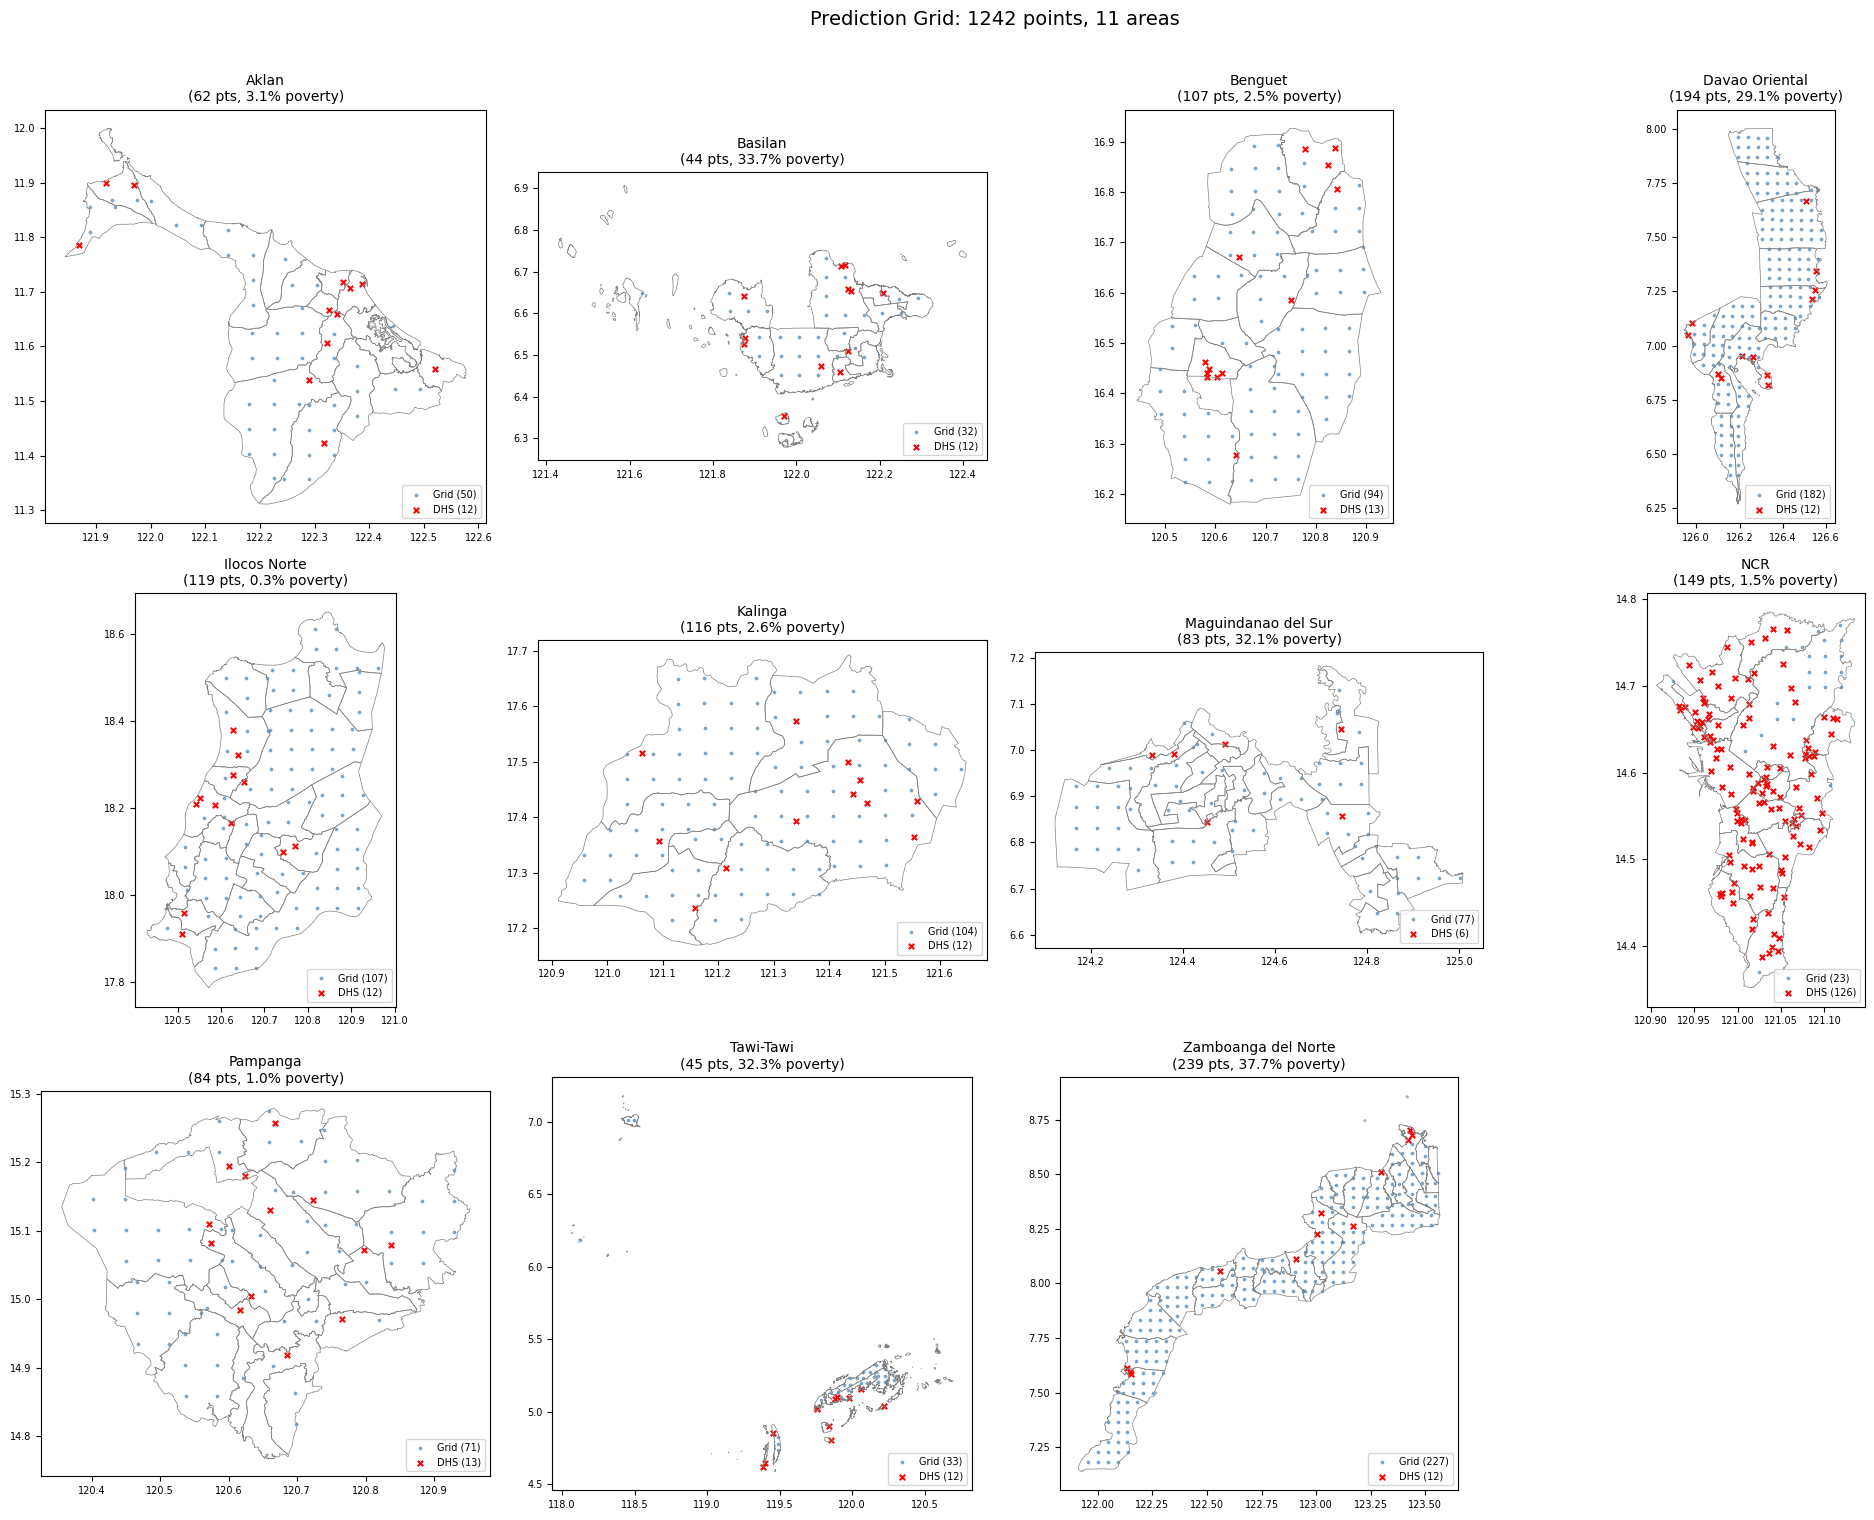

In [77]:
# ============================================================
# 6. QUICK MAP
# ============================================================

import matplotlib.pyplot as plt

provinces = sorted(gdf_out['Province'].unique())
n_prov = len(provinces)
ncols = 4
nrows = (n_prov + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, prov in enumerate(provinces):
    ax = axes[i]
    prov_bounds = gdf_target[gdf_target[COL_PROVINCE] == prov].to_crs('EPSG:4326')
    prov_bounds.boundary.plot(ax=ax, color='gray', linewidth=0.5)

    pts = gdf_out[gdf_out['Province'] == prov]
    grid_pts = pts[pts['source'] == 'grid']
    dhs_pts = pts[pts['source'] == 'DHS']

    if len(grid_pts) > 0:
        ax.scatter(grid_pts['Longitude'], grid_pts['Latitude'],
                   s=3, c='steelblue', alpha=0.6, label=f'Grid ({len(grid_pts)})')
    if len(dhs_pts) > 0:
        ax.scatter(dhs_pts['Longitude'], dhs_pts['Latitude'],
                   s=15, c='red', marker='x', label=f'DHS ({len(dhs_pts)})')

    poverty = POVERTY_RATES.get(prov, '')
    ax.set_title(f"{prov}\n({len(pts)} pts, {poverty}% poverty)", fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Prediction Grid: {len(gdf_out)} points, {n_prov} areas', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/prediction_grid_overview.png', dpi=150, bbox_inches='tight')
plt.show()